# BTSP in a T-maze

* T-maze, largely fixed direction navigation, randomly selecting target arm on each trajectory
* CA3: 40 preset place fields
* CA1: 
  * Hebbian learning + BTSP learning at targeted neurons
  * BTSP learning: long-tailed (pre) Hebbian learning with a high output firing rate considered (occurs in one trajectory only)
  * (1) 1 cell, receives BTSP signal at a reward location

Evaluate resulting CA1 neuron place field properties

In [1]:
import copy
from typing import Any
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import plot_util, params_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

## Reload

In [4]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(params_util);

## T-maze BTSP

 85%|███████████████████████████████▎     | 6778/8000 [00:06<00:01, 1068.80it/s]


Trajectory lengths (11) to date: 18.49 +/- 3.36 sec each
Trajectory lengths (11) to date: 616.27 +/- 112.12 steps each


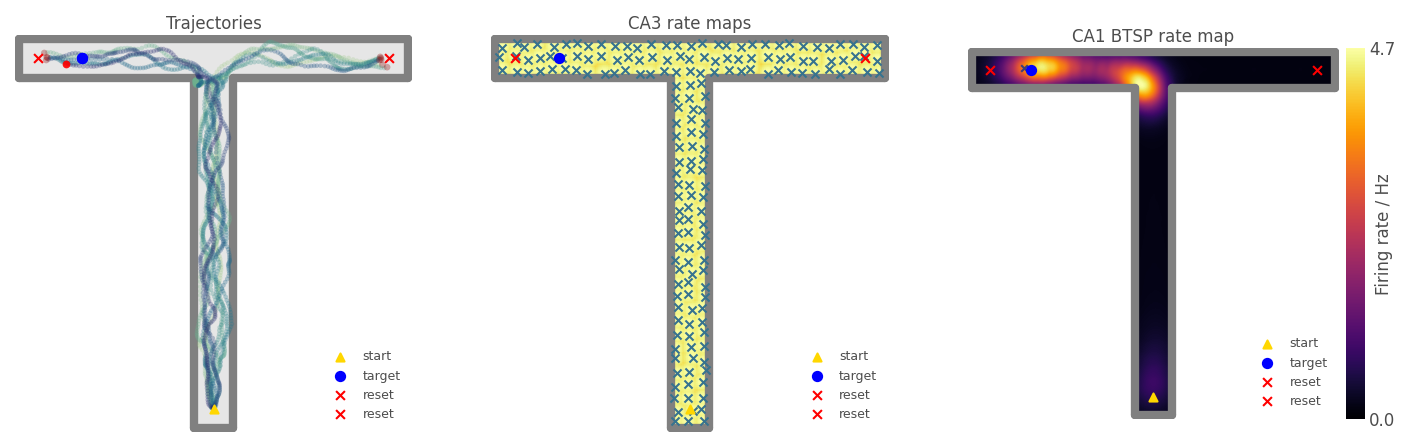

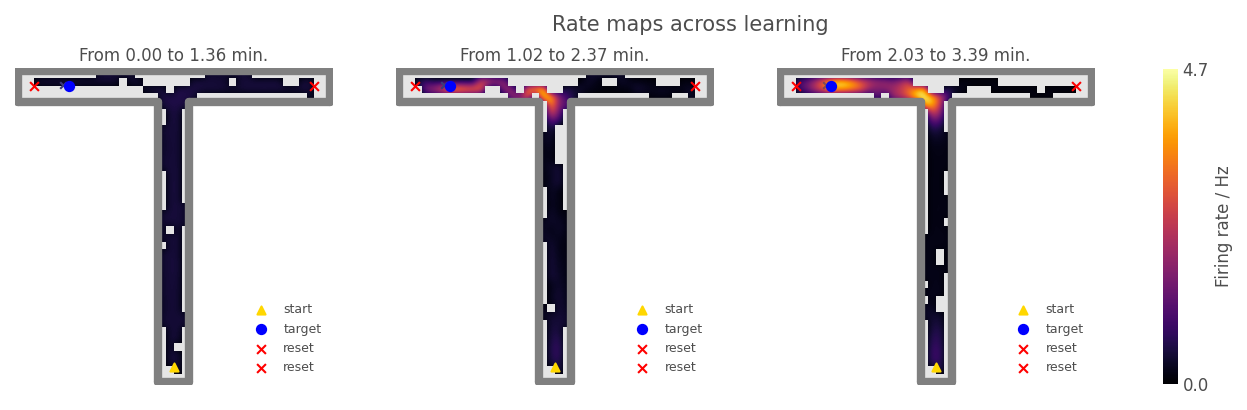

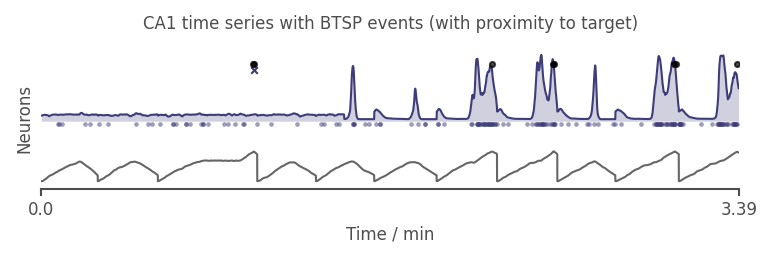

In [5]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter",
)

Env, Ag, _, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    CA3_PC_params=CA3_PC_params,
    num_rewards=8, 
    max_num_steps=8000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2,
    two_compartment=False
)

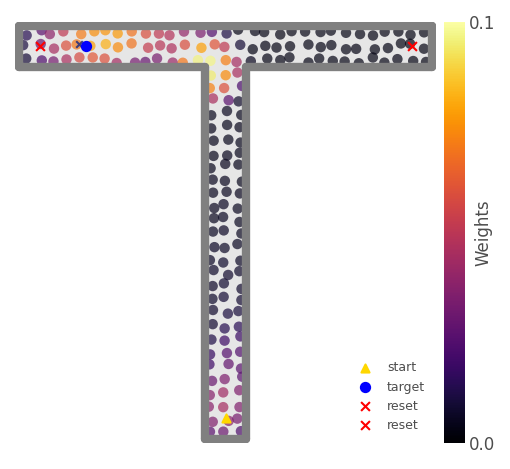

In [6]:
fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s, ax=ax, s=25, plot_BTSP_events=True);

## Distance to target

8


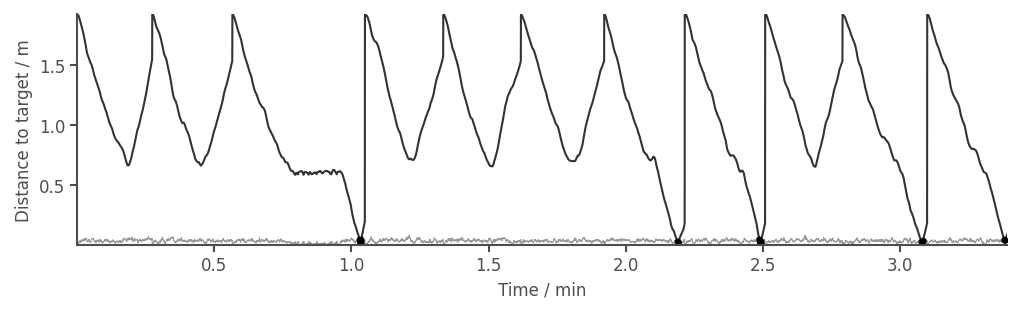

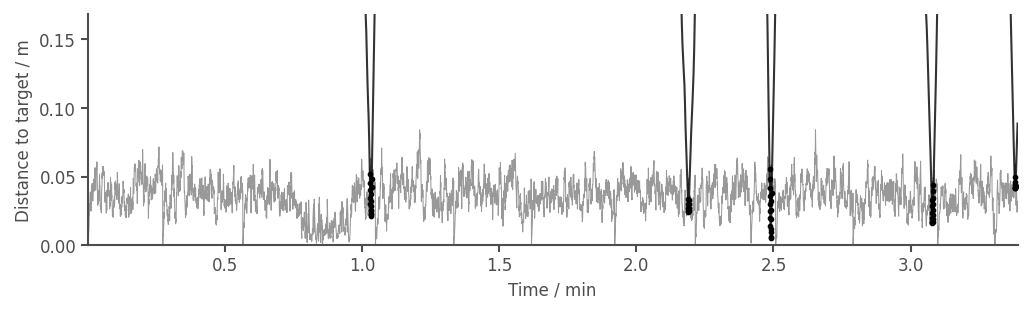

In [7]:
Ag.plot_distance_to(mark_below_tolerance=True)
Ag.plot_distance_to(zoom_prop=2, mark_below_tolerance=True)
print(Ag.target_reached_within_tol_prop_to_speed_dt)

## BTSP filtered inputs

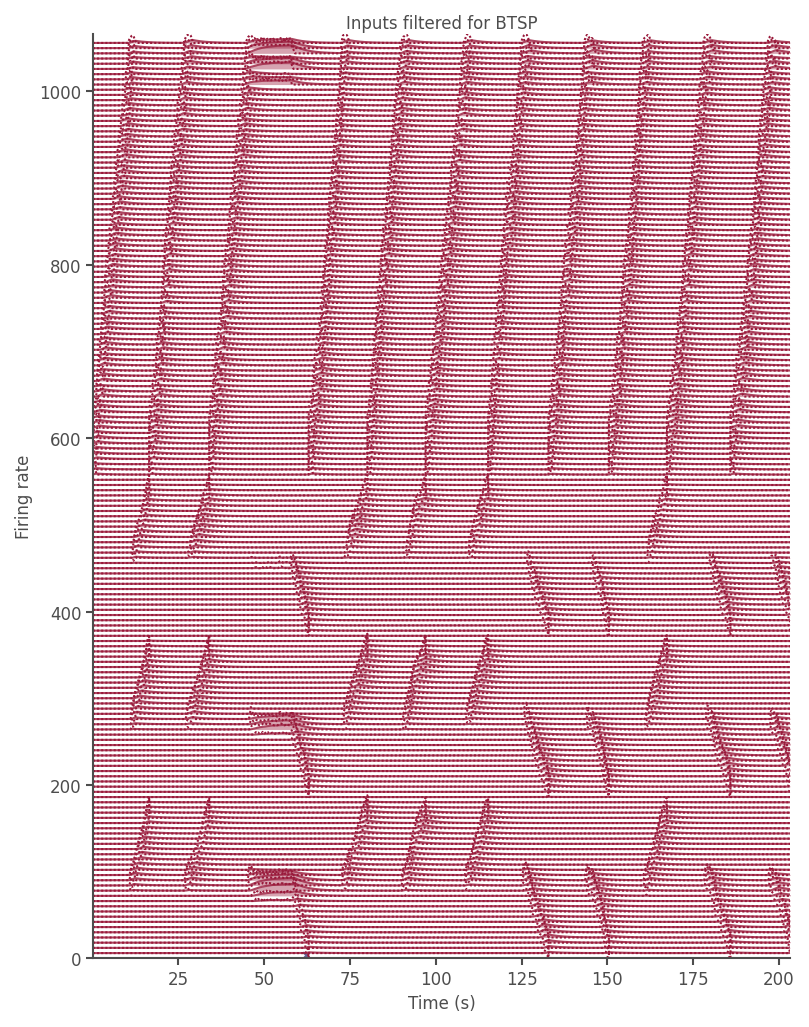

In [8]:
CA1s.plot_filtered_for_BTSP("CA3_PCs");

# BTSP 2-compartment independent

In [9]:
import importlib
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(run_manager)
importlib.reload(plot_util)
importlib.reload(agent)
importlib.reload(env)

from tqdm import tqdm

In [10]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
)

100%|██████████████████████████████████████| 4000/4000 [00:06<00:00, 645.48it/s]


Only reached the reward 7 times (target: 8).
Trajectory lengths (7) to date: 17.14 +/- 4.35 sec each
Trajectory lengths (7) to date: 571.43 +/- 145.07 steps each


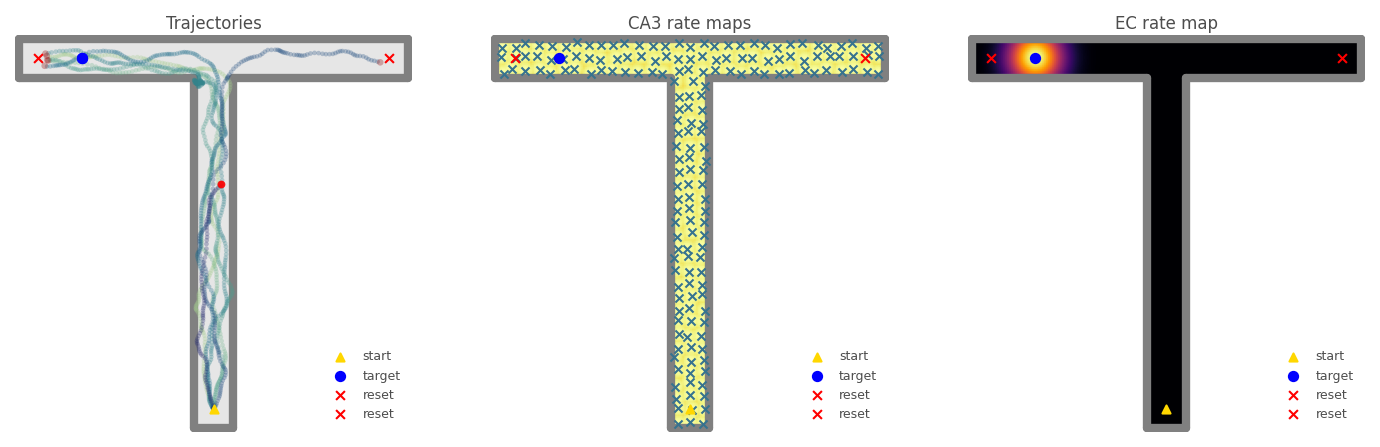

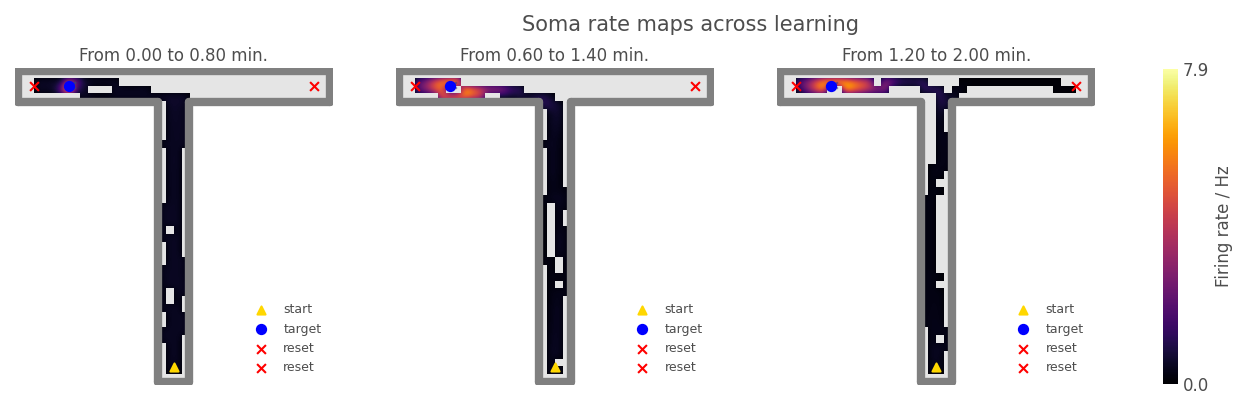

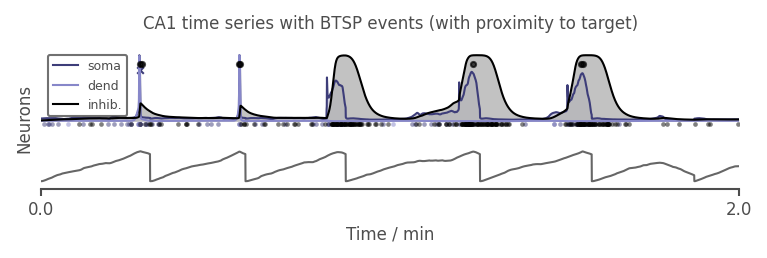

In [11]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=8, 
    max_num_steps=4000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

In [12]:
%debug

ERROR:root:No traceback has been produced, nothing to debug.


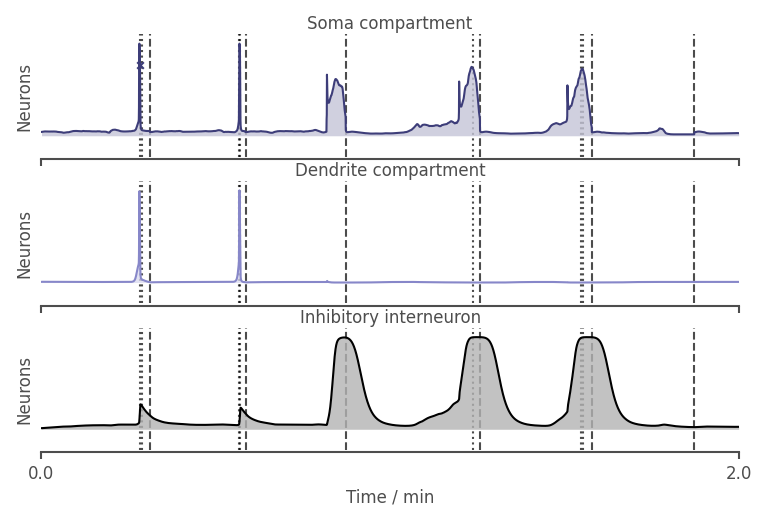

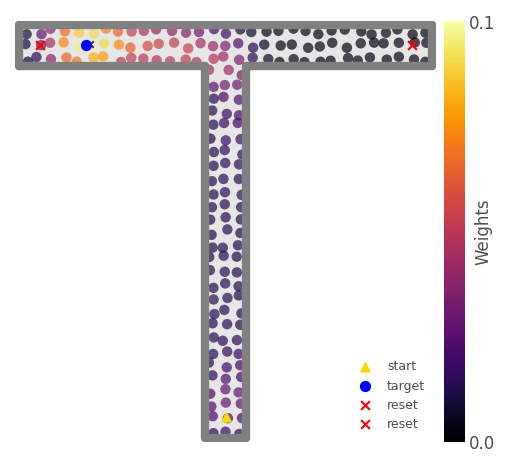

In [13]:
CA1s.plot_rate_timeseries(separate_axes=True)

fig, ax = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax, s=25, plot_BTSP_events=True);

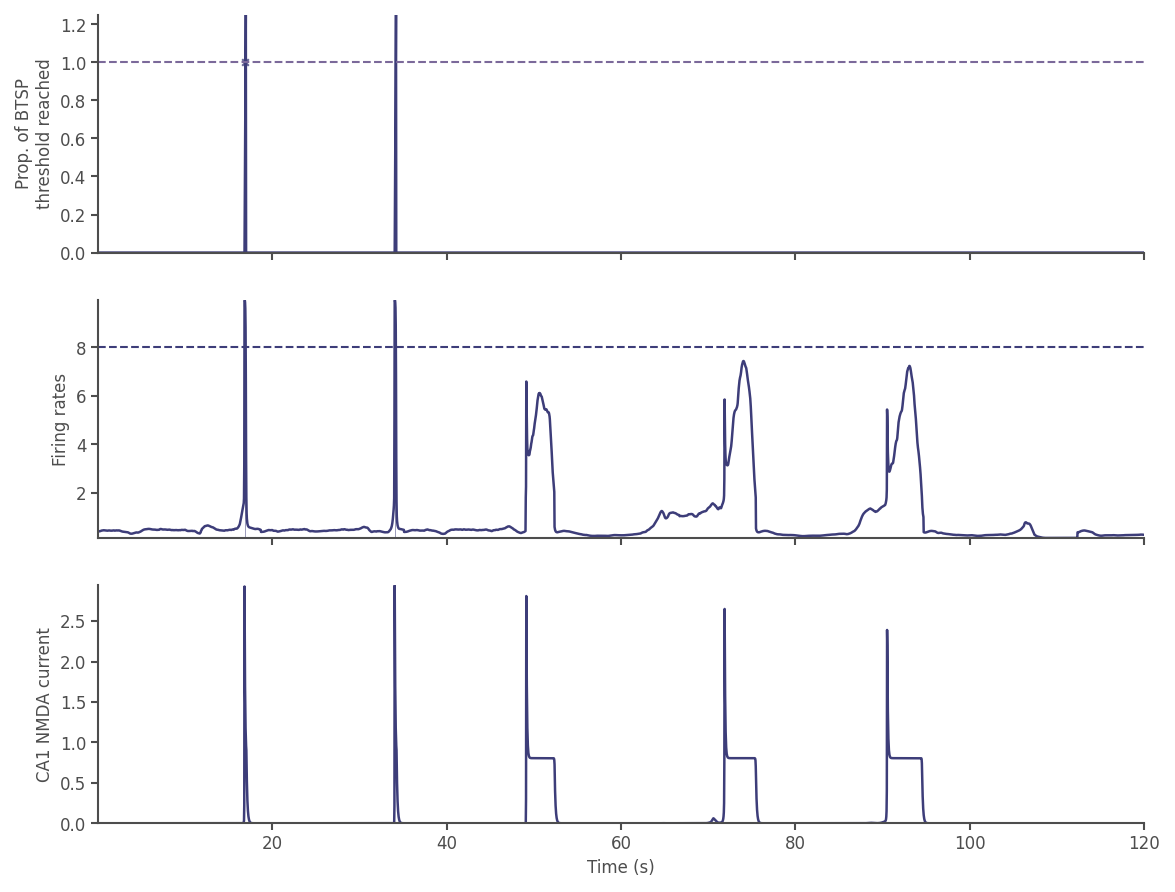

In [14]:
CA1s.SomaCompartment.plot_BTSP_ramp();

BTSP events applied after 1072.00 steps (32.16 sec.) (num steps: 1072).


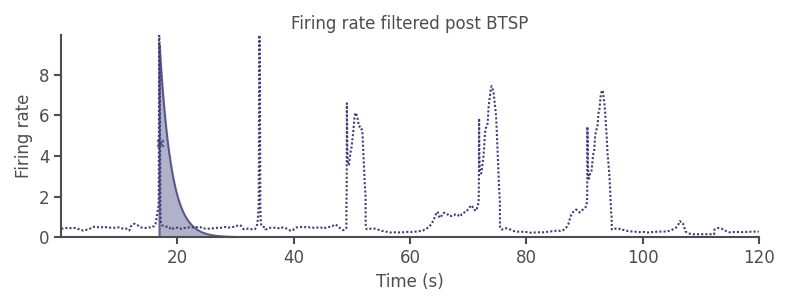

In [15]:
CA1s.SomaCompartment.log_num_steps_to_apply_BTSP()
CA1s.SomaCompartment.plot_filtered_for_BTSP();

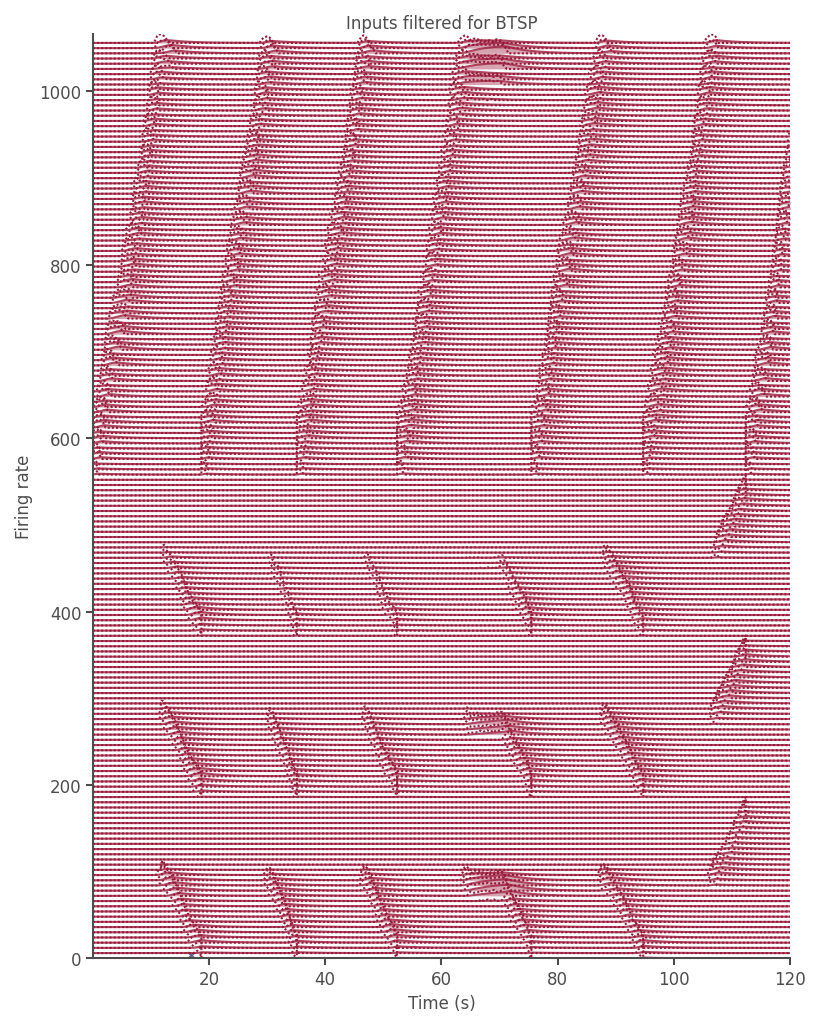

In [16]:
CA1s.SomaCompartment.plot_filtered_for_BTSP("CA3_PCs");

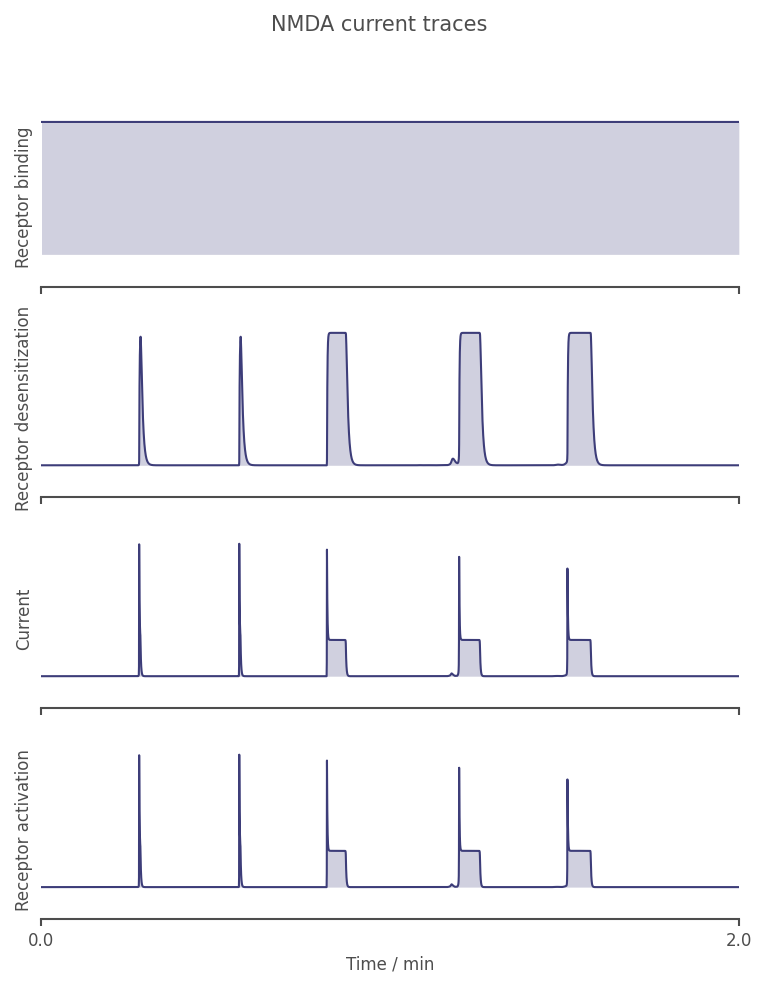

In [17]:
CA1s.SomaCompartment.inputs["NMDACurrent"]["layer"].plot_timeseries(datatypes="all");

In [18]:
Ag.target_df

,target_arm,position_x,position_y,set_step,set_time,reached_step,reached_time,num_steps_total,time_total
0,left,0.325,1.9,0,0.00,563.0,16.89,563.0,16.89
1,left,0.325,1.9,563,16.89,574.0,17.22,11.0,0.33
2,left,0.325,1.9,574,17.22,1130.0,33.90,556.0,16.68
3,left,0.325,1.9,1130,33.90,1141.0,34.23,11.0,0.33
4,left,0.325,1.9,1141,34.23,2472.0,74.16,1331.0,39.93
5,left,0.325,1.9,2472,74.16,3096.0,92.88,624.0,18.72
6,left,0.325,1.9,3096,92.88,3107.0,93.21,11.0,0.33
7,left,0.325,1.9,3107,93.21,NaN,NaN,NaN,NaN


In [19]:
Ag.trajectory_df

,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,1.000179,0.100975,0,0.00,0.137981,1.876692,623.0,18.69,623.0,18.69
1,0.999179,0.099598,623,18.69,0.141632,1.876692,1170.0,35.10,547.0,16.41
2,1.000892,0.099433,1170,35.10,0.141657,1.876692,1745.0,52.35,575.0,17.25
3,1.000143,0.098957,1745,52.35,0.136327,1.876692,2515.0,75.45,770.0,23.10
4,0.998925,0.099770,2515,75.45,0.127227,1.876692,3156.0,94.68,641.0,19.23
5,0.999799,0.098972,3156,94.68,1.865444,1.876692,3744.0,112.32,588.0,17.64
6,1.000350,0.101036,3744,112.32,NaN,NaN,NaN,NaN,NaN,NaN


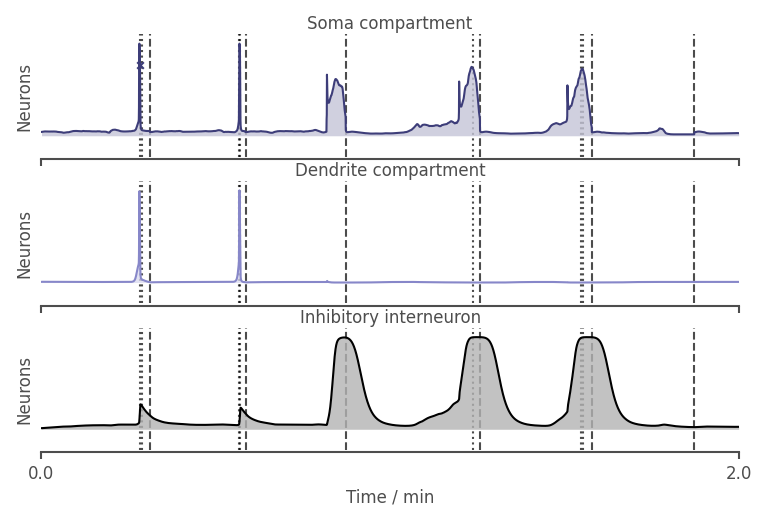

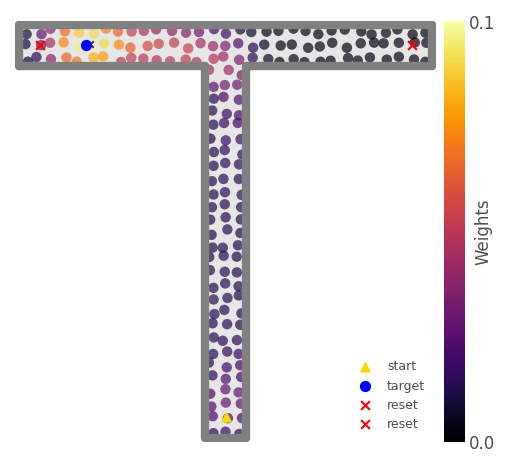

In [20]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Move target

In [21]:
Ag.set_target_position([1, 1.3])

In [22]:
num_steps = 2500
for i in tqdm(range(2500)):
    Ag.update(speed_fact=3, drift_to_random_strength_ratio=1)
    ECs.update()
    CA3_PCs.update()
    CA1s.update()

100%|██████████████████████████████████████| 2500/2500 [00:03<00:00, 661.72it/s]


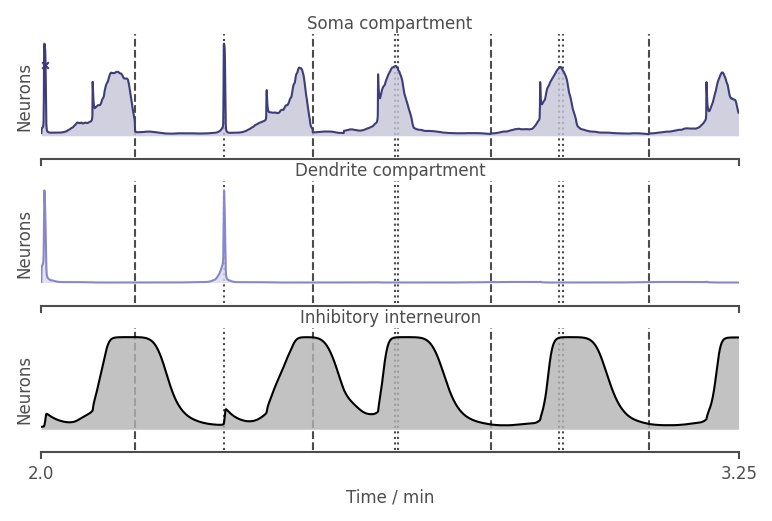

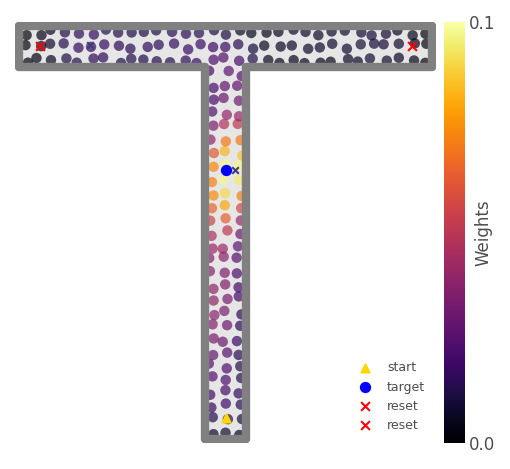

In [23]:
ax_time = CA1s.plot_rate_timeseries(t_start=2*60, separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

## Test wrong parameters

In [24]:
INHIBIT_WEIGHT = 0.5 # too low

In [25]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████████████████████████████████| 6000/6000 [00:09<00:00, 657.65it/s]


Only reached the reward 7 times (target: 12).
Trajectory lengths (10) to date: 18.00 +/- 2.28 sec each
Trajectory lengths (10) to date: 600.00 +/- 76.14 steps each


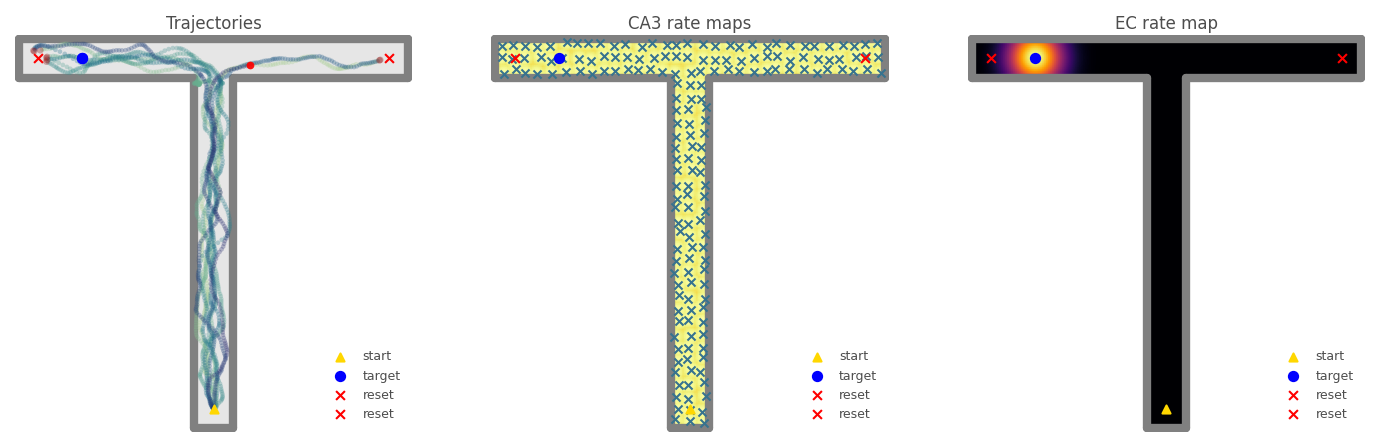

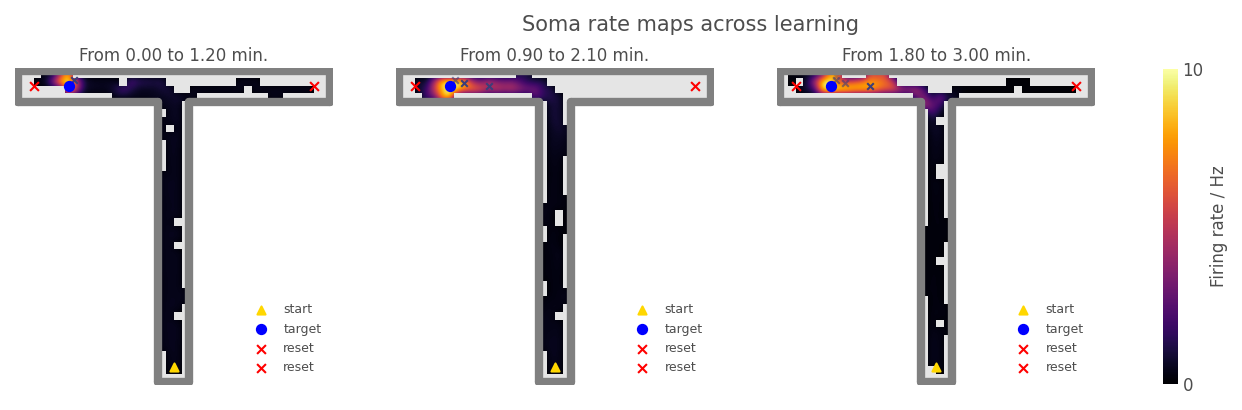

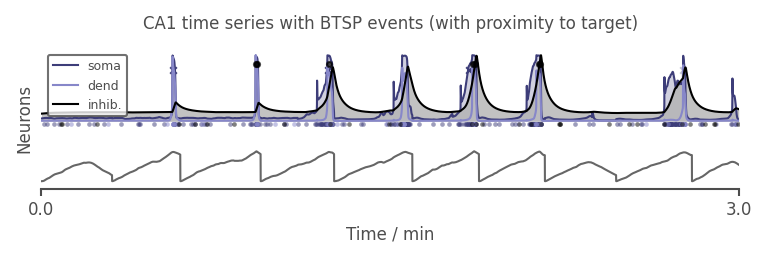

In [26]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

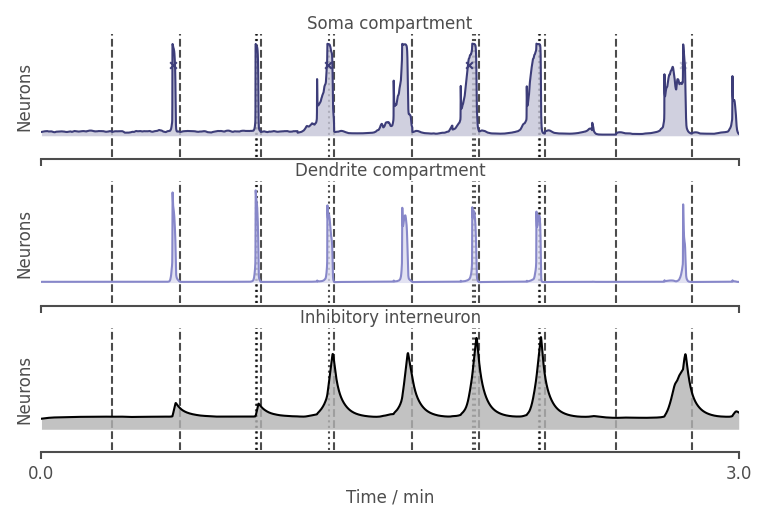

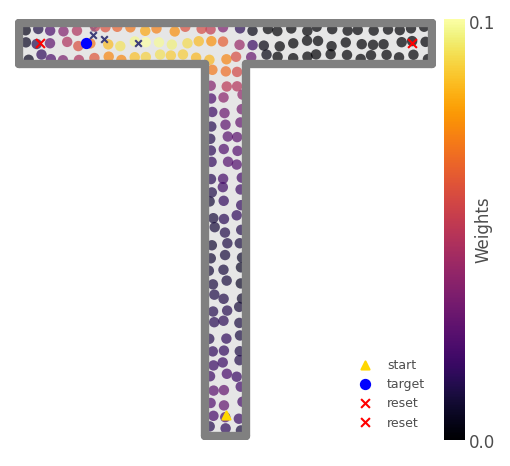

In [27]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);

In [28]:
INHIBIT_WEIGHT = 5.0 # too high

In [29]:
DT = params_util.DT

env_params = params_util.get_env_params(environment="tmaze")

Ag_params = params_util.get_agent_params(
    environment="tmaze", dt=DT, left_arm_prop=0.8
)

CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", place_cell_centres="uniform"
)

CA1_params = params_util.get_CA1_params(
    n=1, environment="tmaze", 
    two_compartment=True, BTSP=True,
    soma_BTSP_lr_fact=400,
    inhibit_weight=INHIBIT_WEIGHT
)

100%|██████████████████████████████████████| 6000/6000 [00:09<00:00, 654.10it/s]


Only reached the reward 11 times (target: 12).
Trajectory lengths (11) to date: 16.36 +/- 3.83 sec each
Trajectory lengths (11) to date: 545.45 +/- 127.53 steps each


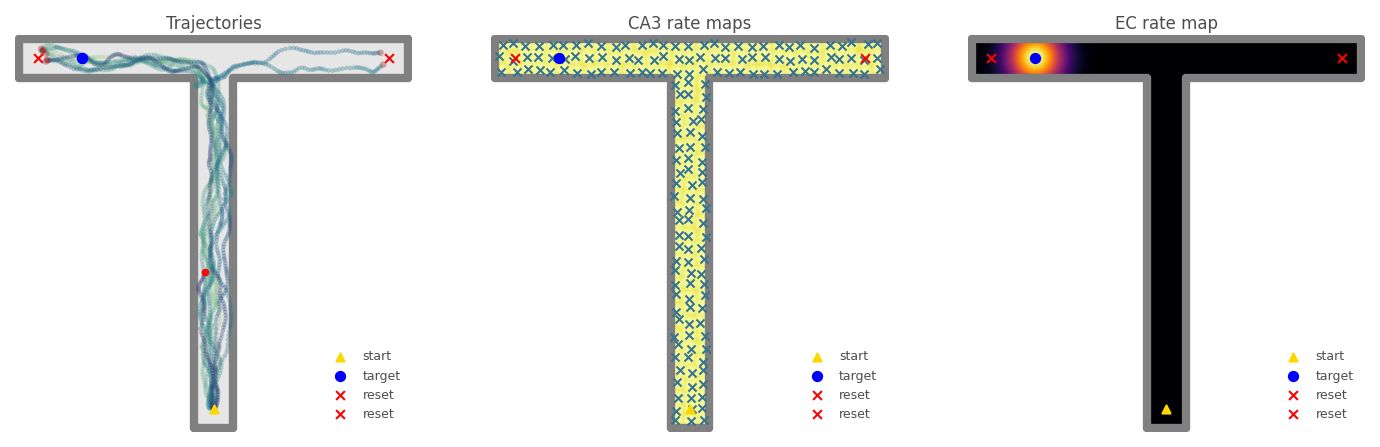

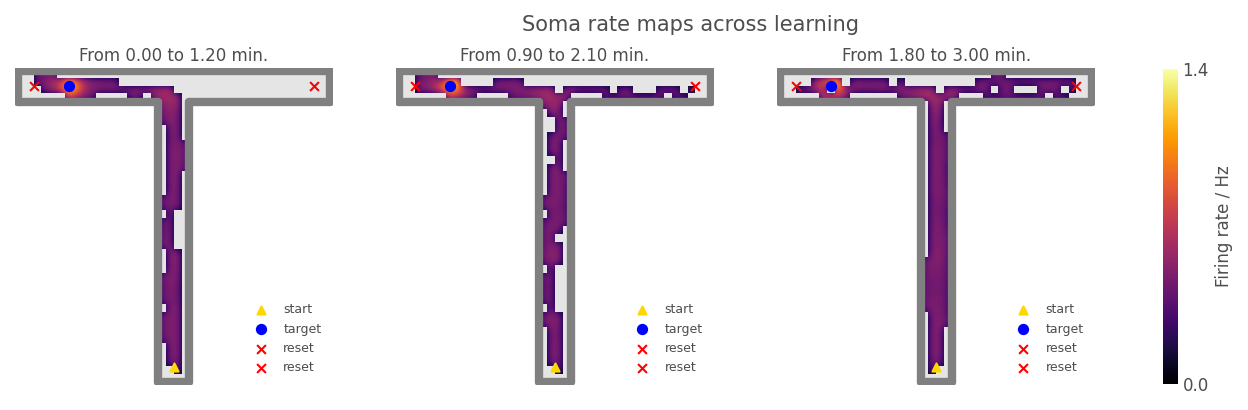

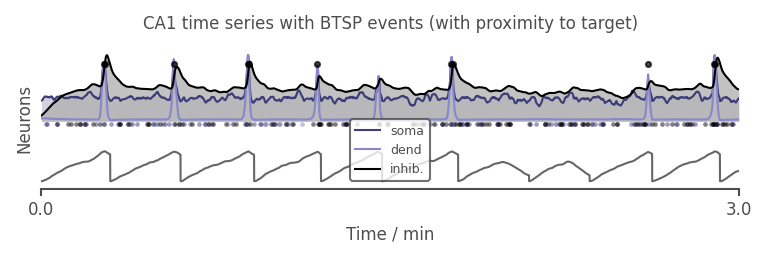

In [30]:
CA3_PC_params = params_util.get_CA3_PC_params(
    environment="tmaze", 
    n=177, # 40, # for one column and one row 
    place_cell_centres="uniform_jitter"
)

Env, Ag, ECs, CA3_PCs, CA1s = run_manager.learn_T_maze_BTSP(
    env_params, 
    Ag_params, 
    CA3_PC_params, 
    CA1_params, 
    num_rewards=12, 
    max_num_steps=6000, 
    weight_recording_freq=100, 
    use_Hebbian=False,
    BTSP_after_num_target_reaches=2, # ignored if 2-compartment
    two_compartment=True
)

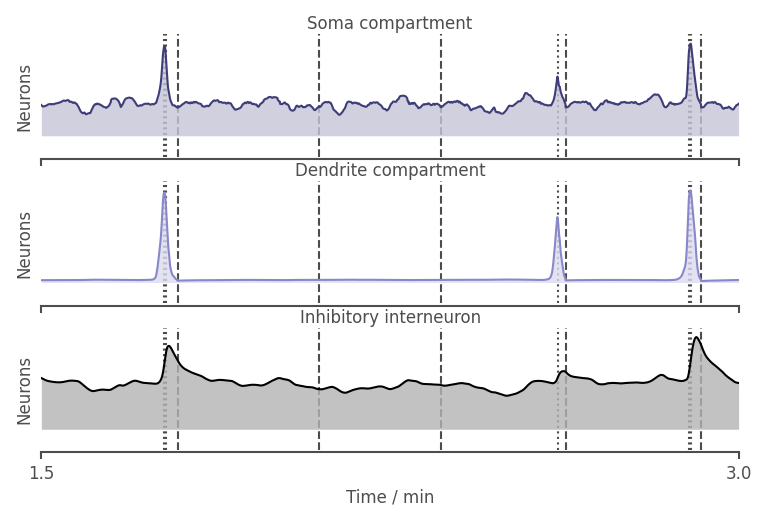

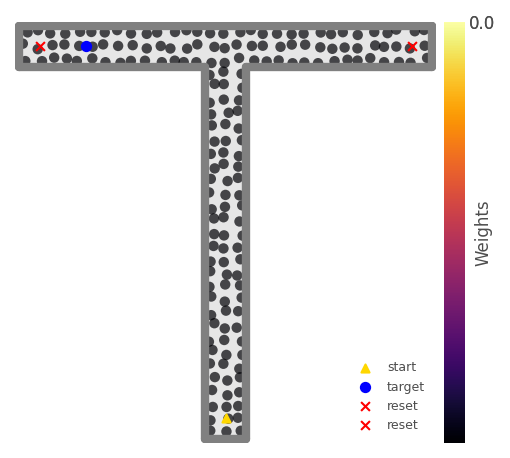

In [31]:
ax_time = CA1s.plot_rate_timeseries(separate_axes=True, t_start=90)

fig_weights, ax_weights = plt.subplots(figsize=[3, 3])
plot_fcts.plot_2D_input_place_cell_weights(CA1s.SomaCompartment, ax=ax_weights, s=25, plot_BTSP_events=True);